**Laboratorio 5: regresion lienal con pytorch**

**Estudiante: Juan De Dios Sullca Rodriguez**

**Materia: Inteligencia Artificial I**

**Dataset: costo de hospitalizacion por accidentes de transito**


**CONFIGURACION INICIAL Y PREPARACION DEL ENTORNO**

para empezar nuestro proyecto lo primero que necesitamos es preparar nuestro espacio de trabajo
en esta celda importamos todas las herramientas principales que daran vida a nuestro modelo de machine learning

pandas y numpy son nuestras herramientas principales para abrir el archivo limpiar los datos y hacer calculos

torch es el motor central con el que vamos a construir y entrenar la red neuronal profunda

sklearn nos servira para dividir los datos y escalar los numeros para que la ia los procese mas rapido

matplotlib es lo que usaremos para dibujar las graficas y ver como aprende el modelo

gc es un truco excelente para limpiar la memoria ram de google colab y evitar que el sistema se trabe

In [ ]:
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import gc # Garbage Collector para liberar RAM
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**CARGA LIMPIEZA Y PREPARACION DE LOS DATOS MEDICOS**

en esta seccion realizamos el trabajo mas importante que es preparar la informacion para que la inteligencia artificial pueda entenderla

primero leemos el archivo de los pacientes directamente desde google drive y seleccionamos unicamente las columnas que realmente nos interesan para el analisis como la edad el sexo el tipo de vehiculo y los detalles del accidente

para cuidar la memoria de nuestra computadora eliminamos el archivo original de inmediato usando el recolector de basura

luego viene la limpieza profunda donde nos aseguramos de que la edad y los costos sean reconocidos como numeros eliminando a los pacientes que no tienen esta informacion o aquellos donde el costo es cero o negativo ya que un costo cero no nos ayuda a predecir gastos hospitalarios

despues aplicamos un secreto profesional usando un logaritmo sobre los costos esto comprime los valores extremos para evitar que una cuenta de hospital de millones de pesos vuelva loco a nuestro modelo durante su aprendizaje

como en la vida real los historiales medicos tienen espacios en blanco separamos nuestros datos y rellenamos esos vacios de forma inteligente poniendo una etiqueta especial en los textos faltantes y usando el valor central o mediana para los numeros asi no perdemos a ningun paciente valioso

luego usamos una funcion especial para convertir todas las palabras y categorias en columnas numericas porque las redes neuronales solo entienden de matematicas y volvemos a limpiar la memoria

por ultimo separamos a nuestros pacientes dejando un grupo grande para entrenar a la maquina y un grupo pequeño para examinarla al final

tambien ajustamos o escalamos todos los valores para que los numeros grandes no opaquen a los pequeños logrando asi que el modelo aprenda de manera equilibrada y sin sesgos

In [ ]:
url = "/content/drive/MyDrive/Inteligencia Artificial I (SIS 420)/Laboratorios/LAB 5/9._Costos_de_la_atención_hospitalaria_en_Bucaramanga_por_accidentes_de_tránsito_enero_2018_a_noviembre_2021_20260304 (1).csv"
df = pd.read_csv(url, encoding='latin-1', low_memory=False)

columnas_seguras = [
    'EDAD', 'SEXO', 'TIPO DE VEHÃ\x8dCULO', 'RELACION USUARIO/ACCIDENTE',
    'OPORTUNIDAD DE LA ATENCIÃ\x93N EN HORAS', 'OPORTUNIDAD DE LA ATENCIÃ\x93N EN MINUTOS',
    'REQUERIMIENTO DE CX', 'REFERIDO A OTRA IPS', 'REGIÃ\x93N ANATÃ\x93MICA MÃ\x81S AFECTADA',
    'POLITRAUMATISMO', 'TIPO AFILIACIÃ\x93N', 'CONDICION EGRESO',
    'GRUPO ETAREO', 'CURSO DE VIDA', 'MES', 'AÃ\x91O', 'DIA SEMANA', 'COSTOS'
]

columnas_existentes = [col for col in columnas_seguras if col in df.columns]
df_filtrado = df[columnas_existentes].copy()
del df
gc.collect()

# Convertimos a numérico por si hay textos escondidos
df_filtrado['COSTOS'] = pd.to_numeric(df_filtrado['COSTOS'], errors='coerce')
df_filtrado['EDAD'] = pd.to_numeric(df_filtrado['EDAD'], errors='coerce')
# 1. Borramos si no hay Edad o no hay Costo
df_filtrado = df_filtrado.dropna(subset=['COSTOS', 'EDAD'])
# 2. Borramos filas donde el Costo sea 0 o negativo.
df_filtrado = df_filtrado[df_filtrado['COSTOS'] > 0]
# ------------------------------------------

# Ahora sí, aplicamos el logaritmo a datos limpios
df_filtrado['COSTOS_LOG'] = np.log1p(df_filtrado['COSTOS'])

X_pandas = df_filtrado.drop(columns=['COSTOS', 'COSTOS_LOG'])
y_pandas = df_filtrado['COSTOS_LOG']

# Relleno de celdas vacías para no perder pacientes
for col in X_pandas.columns:
    if X_pandas[col].dtype == 'object':
        X_pandas[col] = X_pandas[col].fillna('SIN_REGISTRO')
        X_pandas[col] = X_pandas[col].replace(['0', 0], 'SIN_REGISTRO')
    else:
        X_pandas[col] = X_pandas[col].fillna(X_pandas[col].median())

print("Convirtiendo texto a números...")
X_numerico = pd.get_dummies(X_pandas, drop_first=True)

X = X_numerico.values
y = y_pandas.values

del X_pandas, df_filtrado
gc.collect()

# División y Escalado
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler_x = StandardScaler()
scaler_y = StandardScaler()

X_train = scaler_x.fit_transform(X_train)
X_test = scaler_x.transform(X_test)
y_train = scaler_y.fit_transform(y_train.reshape(-1, 1))
y_test = scaler_y.transform(y_test.reshape(-1, 1))

print(f"¡Listo! Datos preparados y limpios. Forma de X_train: {X_train.shape}")

Convirtiendo texto a números...
¡Listo! Datos preparados y limpios. Forma de X_train: (23067, 3054)


**CONSTRUCCION Y ENTRENAMIENTO DE LA RED NEURONAL**

ahora pasamos a la fase de construccion donde primero transformamos nuestros datos a un formato especial llamado tensores que es el lenguaje nativo de pytorch para poder alimentar a nuestra inteligencia artificial agrupamos a los pacientes en lotes de quinientos doce personas lo que nos permite que el modelo aprenda de manera progresiva y estable sin sobrecargar la memoria de la computadora ademas mezclamos los datos de entrenamiento para que la maquina no aprenda de memoria el orden de los pacientes

luego diseñamos la arquitectura de nuestro cerebro artificial creando una red neuronal profunda con varias capas ocultas que se van haciendo mas pequeñas poco a poco para destilar la informacion introducimos una tecnica brillante llamada dropout que apaga aleatoriamente el veinte por ciento de las neuronas en cada paso obligando a la red a encontrar verdaderos patrones logicos en lugar de simplemente memorizar los datos finalmente enviamos todo este modelo a la tarjeta grafica si esta disponible para que los calculos sean extremadamente rapidos

para guiar el aprendizaje elegimos configuraciones muy especificas usamos la perdida de huber que es un secreto fundamental cuando predecimos dinero ya que es muy tolerante a los valores extremos como facturas de hospital gigantescas tambien configuramos un optimizador dando pasos de aprendizaje muy pequeños para evitar que la grafica tiemble y añadimos un programador inteligente que funciona como un freno automatico reduciendo la velocidad de aprendizaje a la mitad si detecta que el modelo se ha estancado

finalmente iniciamos el ciclo de entrenamiento donde le damos trescientas oportunidades o epocas a la red para que intente predecir los costos una y otra vez midiendo su propio error y ajustando sus conexiones internas para mejorar en cada vuelta mientras la maquina estudia los datos de entrenamiento tambien la examinamos constantemente con los datos de validacion y lo mas importante de todo es que el codigo va guardando automaticamente una copia de seguridad del modelo exacto en el momento que obtiene la mejor calificacion asi nos aseguramos de conservar la version mas perfecta posible al terminar ignorando las vueltas donde la red empeoro

In [9]:
class CostosDataset(torch.utils.data.Dataset):
    def __init__(self, X, Y):
        # Convertimos los arrays de numpy a tensores de PyTorch
        self.X = torch.from_numpy(X).float()
        self.Y = torch.from_numpy(Y).float()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, ix):
        return self.X[ix], self.Y[ix]

# Instanciamos los datasets
train_dataset = CostosDataset(X_train, y_train)
test_dataset = CostosDataset(X_test, y_test)

# Creamos los DataLoaders para manejar los datos en "batches" (lotes)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=512, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=512, shuffle=False)

# --- 2. DEFINIR LA RED NEURONAL (Mejorada) ---
input_dim = X_train.shape[1]

model = torch.nn.Sequential(
    torch.nn.Linear(input_dim, 256), # Hicimos la red más ancha
    torch.nn.ReLU(),
    torch.nn.Dropout(0.2),           # Apaga el 20% de las neuronas para evitar que memorice los datos (Overfitting)
    torch.nn.Linear(256, 128),
    torch.nn.ReLU(),
    torch.nn.Dropout(0.2),
    torch.nn.Linear(128, 64),
    torch.nn.ReLU(),
    torch.nn.Linear(64, 1)
)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

# --- 3. CONFIGURACIÓN DEL ENTRENAMIENTO ---
# EL SECRETO: HuberLoss es mucho mejor para predecir dinero con valores extremos
criterion = torch.nn.HuberLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001) # Bajamos un poco la velocidad de aprendizaje (lr)
# Añade el Scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

epochs = 300 # Le damos más tiempo para aprender
best_loss = float('inf')
PATH = './mejor_modelo_costos.pt'
history_train = []
history_val = []
print(f"Iniciando entrenamiento en: {device}...")

for epoch in range(1, epochs + 1):
    model.train()
    train_loss = []

    for x_b, y_b in train_loader:
        x_b, y_b = x_b.to(device), y_b.to(device)
        y_pred = model(x_b)
        loss = criterion(y_pred, y_b)
        train_loss.append(loss.item())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    model.eval()
    val_loss = []
    with torch.no_grad():
        for x_val, y_val in test_loader:
            x_val, y_val = x_val.to(device), y_val.to(device)
            y_pred_val = model(x_val)
            val_loss.append(criterion(y_pred_val, y_val).item())

    avg_train_loss = np.mean(train_loss)
    avg_val_loss = np.mean(val_loss)
    scheduler.step(avg_val_loss)

    history_train.append(avg_train_loss)
    history_val.append(avg_val_loss)

    if avg_val_loss < best_loss:
        best_loss = avg_val_loss
        torch.save(model.state_dict(), PATH)
        estado = " --> ¡Nuevo mejor modelo guardado!"
    else:
        estado = ""

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch}/{epochs} | Val Loss: {avg_val_loss:.4f}{estado}")

print("\n¡Entrenamiento finalizado!")

Iniciando entrenamiento en: cpu...
Epoch 1/300 | Val Loss: 0.3679 --> ¡Nuevo mejor modelo guardado!
Epoch 10/300 | Val Loss: 0.3082 --> ¡Nuevo mejor modelo guardado!
Epoch 20/300 | Val Loss: 0.3063 --> ¡Nuevo mejor modelo guardado!
Epoch 30/300 | Val Loss: 0.3109
Epoch 40/300 | Val Loss: 0.3114
Epoch 50/300 | Val Loss: 0.3110
Epoch 60/300 | Val Loss: 0.3112
Epoch 70/300 | Val Loss: 0.3114
Epoch 80/300 | Val Loss: 0.3114
Epoch 90/300 | Val Loss: 0.3114
Epoch 100/300 | Val Loss: 0.3114
Epoch 110/300 | Val Loss: 0.3114
Epoch 120/300 | Val Loss: 0.3114
Epoch 130/300 | Val Loss: 0.3114
Epoch 140/300 | Val Loss: 0.3114
Epoch 150/300 | Val Loss: 0.3114
Epoch 160/300 | Val Loss: 0.3114
Epoch 170/300 | Val Loss: 0.3114
Epoch 180/300 | Val Loss: 0.3114
Epoch 190/300 | Val Loss: 0.3114
Epoch 200/300 | Val Loss: 0.3114
Epoch 210/300 | Val Loss: 0.3114
Epoch 220/300 | Val Loss: 0.3114
Epoch 230/300 | Val Loss: 0.3114
Epoch 240/300 | Val Loss: 0.3114
Epoch 250/300 | Val Loss: 0.3114
Epoch 260/300 | 

**VISUALIZACION DEL APRENDIZAJE DEL MODELO**

ahora vamos a crear una grafica para ver visualmente como aprendio nuestra inteligencia artificial a lo largo del tiempo

usamos la libreria matplotlib para dibujar dos lineas muy importantes en un lienzo amplio la primera linea azul representara el costo de entrenamiento es decir como el modelo fue reduciendo sus errores mientras estudiaba los datos de los pacientes

la segunda linea sera de color naranja y punteada y nos mostrara el costo de validacion que es el resultado de los examenes que le haciamos con pacientes que la red nunca habia visto antes

añadimos titulos descriptivos a los ejes para saber que estamos viendo el numero de iteraciones o epocas frente a la cantidad de error o costo que comete la maquina en sus predicciones

finalmente le ponemos una cuadricula de fondo y una leyenda para que la grafica sea muy facil de entender a simple vista y nos revele claramente si nuestro modelo realmente logro aprender los patrones generales de los costos hospitalarios o si hubo algun problema de sobreajuste durante el proceso

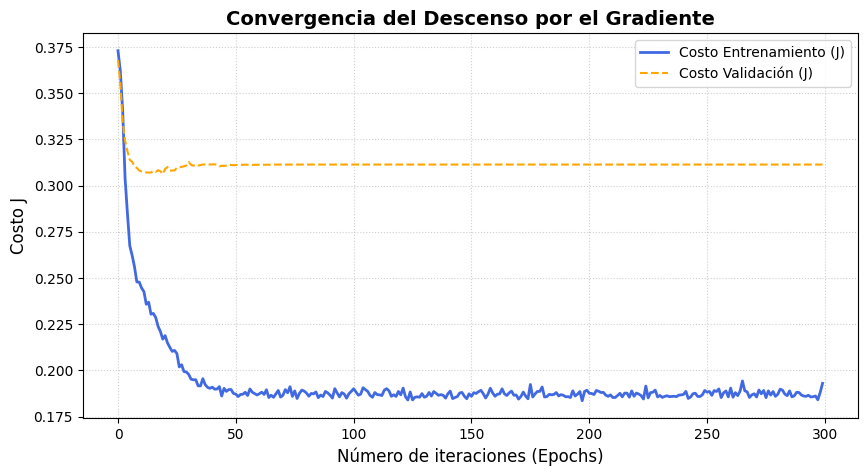

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(history_train, label='Costo Entrenamiento (J)', color='royalblue', linewidth=2)
plt.plot(history_val, label='Costo Validación (J)', color='orange', linestyle='--')

plt.title('Convergencia del Descenso por el Gradiente', fontsize=14, fontweight='bold')
plt.xlabel('Número de iteraciones (Epochs)', fontsize=12)
plt.ylabel('Costo J', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

**EVALUACION DEL PACIENTE REAL Y EXPORTACION DEL MODELO**

ahora llegamos a la parte donde ponemos a prueba todo nuestro trabajo con un caso de la vida real
lo primero que hacemos es cargar esa copia de seguridad perfecta que el programa guardo durante el entrenamiento y ponemos a la red en modo de evaluacion para que sepa que ya es hora del examen final y no debe alterar sus conocimientos

luego elegimos a un paciente especifico de nuestro grupo de pruebas y le pedimos a la inteligencia artificial que analice sus datos para predecir su costo hospitalario
como antes habiamos modificado los numeros para ayudar a la red a aprender ahora tenemos que hacer todo el proceso al reves
primero deshacemos el escalado matematico y despues usamos una funcion especial para revertir el logaritmo que aplicamos al principio
gracias a esto la prediccion vuelve a convertirse en dinero real y podemos ver en pantalla la comparacion exacta entre la factura real del hospital y lo que adivino la maquina

finalmente empaquetamos nuestro modelo para que pueda ser utilizado en el mundo exterior
lo exportamos en dos formatos profesionales diferentes incluyendo onnx que es un estandar universal de la industria
esto significa que el modelo ya esta listo para ser integrado en una aplicacion de celular un tablero de control para el hospital o cualquier otro sistema moderno sin importar el lenguaje de programacion que usen los desarrolladores

In [11]:
# --- 1. CARGAR EL MEJOR MODELO ---
PATH = './mejor_modelo_costos.pt'
model.load_state_dict(torch.load(PATH))
model.eval()
model.cpu()

# --- 2. EVALUACIÓN Y PREDICCIÓN REAL ---
indice_paciente = 5
paciente_x = torch.tensor(X_test[indice_paciente:indice_paciente+1]).float()
costo_real_escalado = y_test[indice_paciente:indice_paciente+1]

with torch.no_grad():
    prediccion_escalada = model(paciente_x)

# Primero deshacemos el StandardScaler
costo_real_log = scaler_y.inverse_transform(costo_real_escalado)
prediccion_log = scaler_y.inverse_transform(prediccion_escalada.numpy())

# Segundo: ¡Descomprimimos el logaritmo para ver el dinero real!
costo_real = np.expm1(costo_real_log)
prediccion_real = np.expm1(prediccion_log)

print("--- RESULTADO DE PREDICCIÓN MEJORADA ---")
print(f"Costo Real del paciente: ${costo_real[0][0]:,.2f}")
print(f"Costo Predicho por la IA: ${prediccion_real[0][0]:,.2f}")
print("-" * 30)

# --- 3. EXPORTACIÓN ---
traced_model = torch.jit.trace(model, paciente_x)
traced_model.save('modelo_costos_traced.zip')

# Install onnxscript if not already installed
try:
    import onnxscript
except ImportError:
    !pip install onnxscript
    import onnxscript

torch.onnx.export(
    model,
    paciente_x,
    "modelo_costos.onnx",
    export_params=True,
    opset_version=18,
    do_constant_folding=True,
    input_names=['input'],
    output_names=['output']
)
print(" Modelo exportado limpiamente.")

--- RESULTADO DE PREDICCIÓN MEJORADA ---
Costo Real del paciente: $69,917.00
Costo Predicho por la IA: $84,976.56
------------------------------
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 9.9 MB/s eta 0:00:00
[torch.onnx] Obtain model graph for `Sequential([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `Sequential([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
 Modelo exportado limpiamente.


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


**GRAFICA FINAL DE RENDIMIENTO Y COMPARACION GLOBAL**

para cerrar nuestro proyecto con broche de oro vamos a evaluar el rendimiento de la inteligencia artificial con todos los pacientes de prueba al mismo tiempo

primero nos aseguramos de que el modelo este en modo de evaluacion y funcionando en el procesador principal de la computadora para evitar consumir recursos graficos innecesarios

luego le pasamos de golpe todos los datos de los pacientes que habiamos reservado para el examen final y le pedimos que genere sus predicciones sin modificar lo que ya aprendio

como la red neuronal nos devuelve numeros escalados matematicamente los convertimos de vuelta a valores reales para poder entenderlos en terminos de dinero

despues construimos una grafica muy visual donde cada punto azul representa a un paciente comparando lo que costo su tratamiento en la vida real contra lo que nuestra maquina calculo

para que sea mas facil interpretar los resultados dibujamos una linea roja diagonal que representa la perfeccion absoluta

si nuestro modelo fuera cien por ciento exacto todos los puntos azules caerian exactamente sobre esa linea roja asi que mientras mas cerca esten los puntos de la linea mejor es nuestra inteligencia artificial

finalmente añadimos detalles esteticos como los nombres de los ejes y nos aseguramos de que los numeros de dinero se muestren completos y no en formatos cientificos para que cualquier persona en el hospital pueda entender la grafica sin ser un experto en matematicas

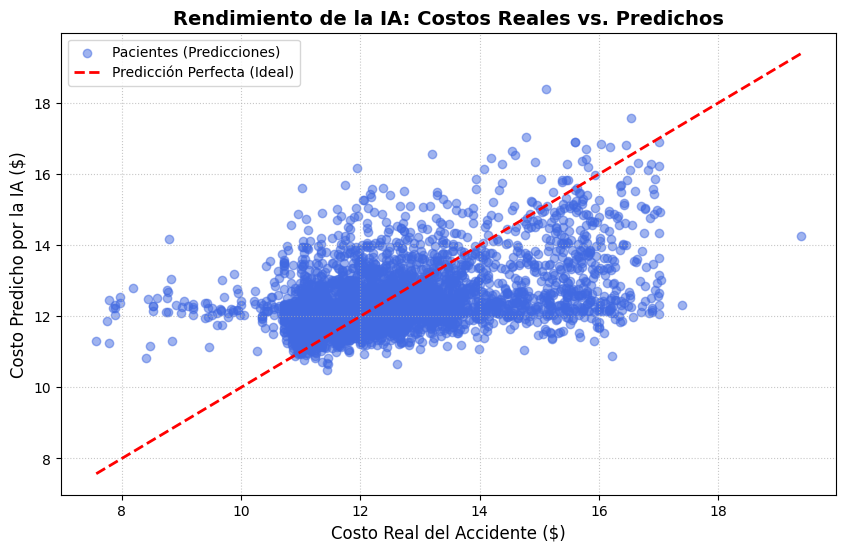

In [12]:
# 1. Asegurarnos que el modelo está en modo evaluación y en la CPU
model.eval()
model.cpu()

# 2. Hacer predicciones para TODO el conjunto de prueba (X_test)
with torch.no_grad():
    tensor_x_test = torch.tensor(X_test).float()
    todas_predicciones_escaladas = model(tensor_x_test)

# 3. Volver a convertir los valores a dinero real (des-normalizar)
costos_reales = scaler_y.inverse_transform(y_test)
costos_predichos = scaler_y.inverse_transform(todas_predicciones_escaladas.numpy())

# 4. CREAR LA GRÁFICA
plt.figure(figsize=(10, 6))

# Puntitos azules: lo que predijo la IA vs lo que realmente costó
plt.scatter(costos_reales, costos_predichos, alpha=0.5, color='royalblue', label='Pacientes (Predicciones)')

# Línea roja: El ideal (si el modelo fuera 100% exacto, todos los puntos caerían sobre esta línea)
min_val = min(costos_reales.min(), costos_predichos.min())
max_val = max(costos_reales.max(), costos_predichos.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Predicción Perfecta (Ideal)')

# 5. Detalles estéticos
plt.title('Rendimiento de la IA: Costos Reales vs. Predichos', fontsize=14, fontweight='bold')
plt.xlabel('Costo Real del Accidente ($)', fontsize=12)
plt.ylabel('Costo Predicho por la IA ($)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

# Para que los números de dinero no salgan en notación científica (ej. 1e6)
plt.ticklabel_format(style='plain', axis='both')

plt.show()

**RESUMEN GENERAL DEL PROYECTO DE PREDICCION DE COSTOS HOSPITALARIOS**

en este proyecto construimos una inteligencia artificial desde cero para predecir cuanto costara la atencion medica de pacientes por accidentes de transito

primero tomamos un archivo lleno de historiales medicos y lo limpiamos profundamente eliminando errores rellenando vacios y transformando palabras en numeros para que la computadora pudiera entender todo ademas usamos trucos matematicos como el logaritmo y el escalado para que los costos extremos no confundieran a la maquina

despues diseñamos el cerebro de nuestra inteligencia artificial usando una red neuronal profunda que analiza los datos por lotes y le enseñamos a aprender de sus propios errores usando herramientas avanzadas como la perdida de huber y un programador automatico que evita que memorice los datos en lugar de entenderlos verdaderamente

durante el proceso creamos graficas para vigilar como iba aprendiendo y nos aseguramos de guardar automaticamente la version mas inteligente de nuestra red justo antes de que empezara a cometer errores o a estancarse

finalmente pusimos a prueba nuestro modelo tanto con un paciente individual como con todos los pacientes de prueba al mismo tiempo transformando los resultados matematicos a dinero real para crear una grafica final que compara los costos verdaderos con las predicciones y empaquetamos todo el sistema en formatos profesionales universales para que pueda ser implementado en cualquier aplicacion o sistema de un hospital real